In [ ]:
# dataset path:  https://universe.roboflow.com/project-gcm3p/pneumoni-detection-3-practical-by-me

# installing required libraries
!pip install roboflow


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mlOW9MXyMKSp8qJPp7wy")
project = rf.workspace("project-gcm3p").project("pneumoni-detection-3-practical-by-me")
version = project.version(1)
dataset_path = version.download("yolov12").location
print(f"Dataset downloaded to: {dataset_path}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pneumoni-detection-3--(Practical-BY-me-)-1 in yolov12:: 100%|██████████| 7140/7140 [00:02<00:00, 2872.97it/s]

Dataset downloaded to: /content/Pneumoni-detection-3--(Practical-BY-me-)-1


In [ ]:
import os

# Define the dataset path
dataset_path = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1"

# Define image and mask directories
image_dir = os.path.join(dataset_path, "images")
mask_dir = os.path.join(dataset_path, "masks")

print(f"Dataset downloaded to: {dataset_path}")

# List all files and directories in the dataset path
print(f"Contents of the dataset folder: {os.listdir(dataset_path)}")




Dataset downloaded to: /content/Pneumoni-detection-3--(Practical-BY-me-)-1
Contents of the dataset folder: ['test', 'train', 'README.dataset.txt', 'valid', 'README.roboflow.txt', 'data.yaml']


In [ ]:
# Set path to dataset
dataset_path = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1"

# Print out the directory structure to see where images and masks are stored
for root, dirs, files in os.walk(dataset_path):
    print(f"Current directory: {root}")
    print(f"Subdirectories: {dirs}")
    print(f"Files: {files}")
    print("="*50)

Current directory: /content/Pneumoni-detection-3--(Practical-BY-me-)-1
Subdirectories: ['test', 'train', 'valid']
Files: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml']
Current directory: /content/Pneumoni-detection-3--(Practical-BY-me-)-1/test
Subdirectories: ['labels', 'images']
Files: []
Current directory: /content/Pneumoni-detection-3--(Practical-BY-me-)-1/test/labels
Subdirectories: []
Files: ['person261_bacteria_1225_jpeg.rf.3ffc1a935ae370b9551810499cf073f0.txt', 'person586_bacteria_2418_jpeg.rf.35a0d58bbc034486e95364f172a5ad0b.txt', 'person1211_virus_2056_jpeg.rf.e0cf3d082f70ba8c62c13a4805ca15ec.txt', 'person38_bacteria_192_jpeg.rf.81de5b83ae78d8c57cda60a0186da179.txt', 'person788_virus_1419_jpeg.rf.92e1e4860cd2791ff48018050230fc95.txt', 'person139_bacteria_664_jpeg.rf.c9ecbb2f92d0b0ae78a2eb0a9670ecf5.txt', 'IM-0584-0001_jpeg.rf.09ce9d458ca7ab371c596c6dcbb7ef01.txt', 'person130_bacteria_626_jpeg.rf.34c660693587effbc496a86c7575e6c3.txt', 'person281_bacteria_1330_jpeg.r

In [ ]:
train_img_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/images"
all_files = os.listdir(train_img_dir)
print("Sample files in training image directory:")
print(all_files[:5])  # print first 5 files

Sample files in training image directory:
['IM-0437-0001_jpeg.rf.83e0c457239224d97c996d2c7edc85fc.jpg', 'person174_bacteria_832_jpeg.rf.7f75adfc68c6a6730f264f060efe65aa.jpg', 'person124_bacteria_589_jpeg.rf.5ec7365a6f3d01a6794ed00a87b1064c.jpg', 'IM-0017-0001_jpeg.rf.223cdb0c3095c21e9b4c14d4524fa891.jpg', 'person1916_bacteria_4821_jpeg.rf.b232e8b6f4ab8137df248ba6dee43c45.jpg']


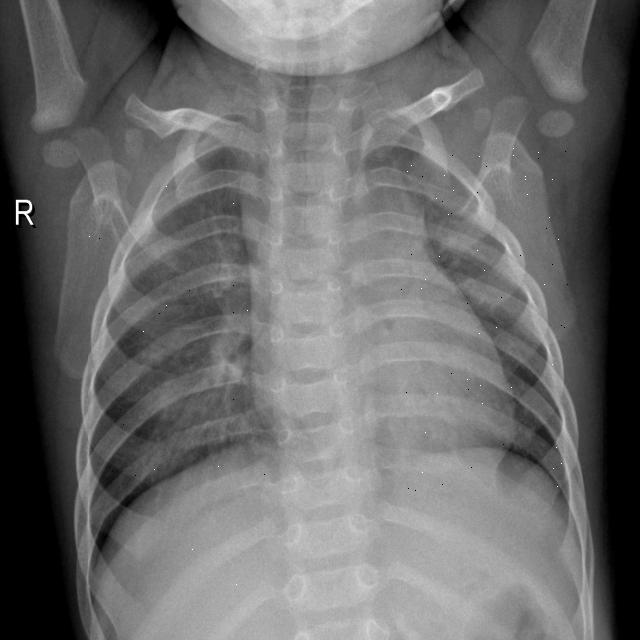

In [ ]:
from IPython.display import Image, display

# Define path to the 'train' images directory
train_images_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/images"

# List all image files in the 'train/images' directory
image_files = os.listdir(train_images_dir)

# Choose a sample image file (e.g., the first one in the list)
sample_image = image_files[0]

# Show the sample image
display(Image(filename=os.path.join(train_images_dir, sample_image), width=600))

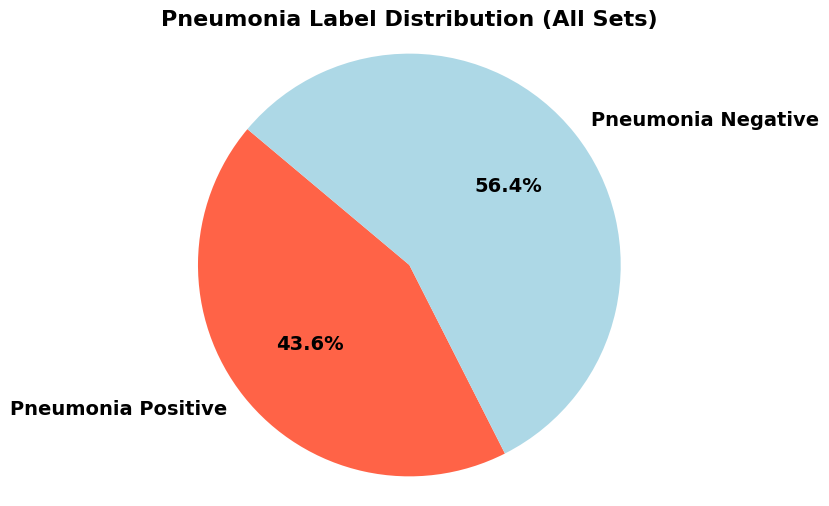

In [ ]:
import matplotlib.pyplot as plt

# Label info based on your provided numbers
labels = ['Pneumonia Positive', 'Pneumonia Negative']
total_counts = [3462, 4482]

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(total_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=['tomato', 'lightblue'],
        textprops={'fontsize': 14, 'fontweight': 'bold'})  # Increase font size

# Title with larger font size
plt.title('Pneumonia Label Distribution (All Sets)', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')
plt.show()


Feature matrix shape: (65536, 5)


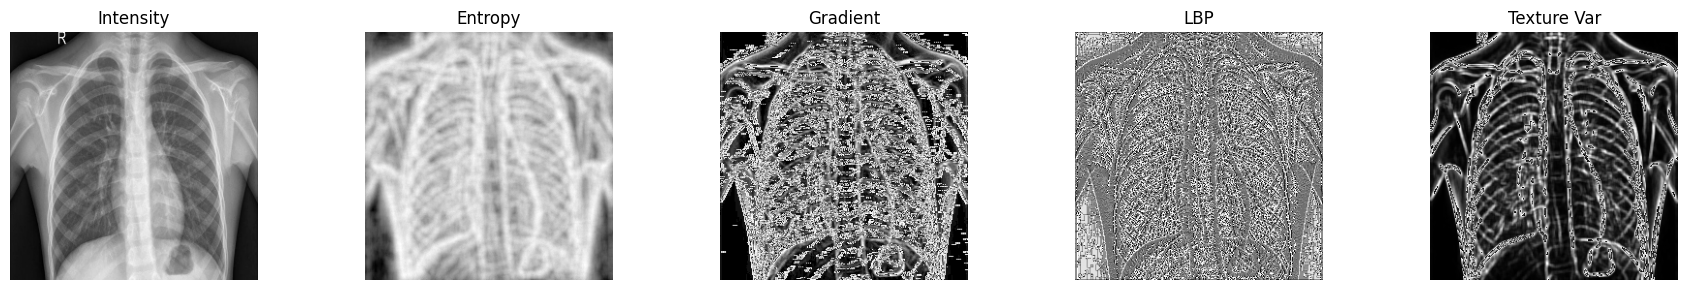

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy.ndimage import gaussian_gradient_magnitude, generic_filter
from skimage import img_as_ubyte

# Define path to the 'train' images directory
train_images_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/images"

# List all image files in the 'train/images' directory
image_files = sorted([f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
sample_image_path = os.path.join(train_images_dir, image_files[0])

# Load and preprocess image
img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))  # standardize size

# Feature 1: Intensity
f1 = img.astype(np.float32)

# Feature 2: Local Entropy
f2 = entropy(img_as_ubyte(img), disk(5)).astype(np.float32)

# Feature 3: Gradient Magnitude
f3 = gaussian_gradient_magnitude(img, sigma=1).astype(np.float32)

# Feature 4: Local Binary Pattern
f4 = local_binary_pattern(img, P=8, R=1, method="uniform").astype(np.float32)

# Feature 5: Local Texture Variance
f5 = generic_filter(img, np.var, size=5).astype(np.float32)

# Stack features into a feature matrix (each pixel = 5-dim vector)
H, W = img.shape
features = np.stack([f1, f2, f3, f4, f5], axis=-1).reshape(-1, 5)
print("Feature matrix shape:", features.shape)  # Should be (256*256, 5)

# Visualize feature maps
fig, axs = plt.subplots(1, 5, figsize=(18, 3))
titles = ['Intensity', 'Entropy', 'Gradient', 'LBP', 'Texture Var']
for ax, data, title in zip(axs, [f1, f2, f3, f4, f5], titles):
    ax.imshow(data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


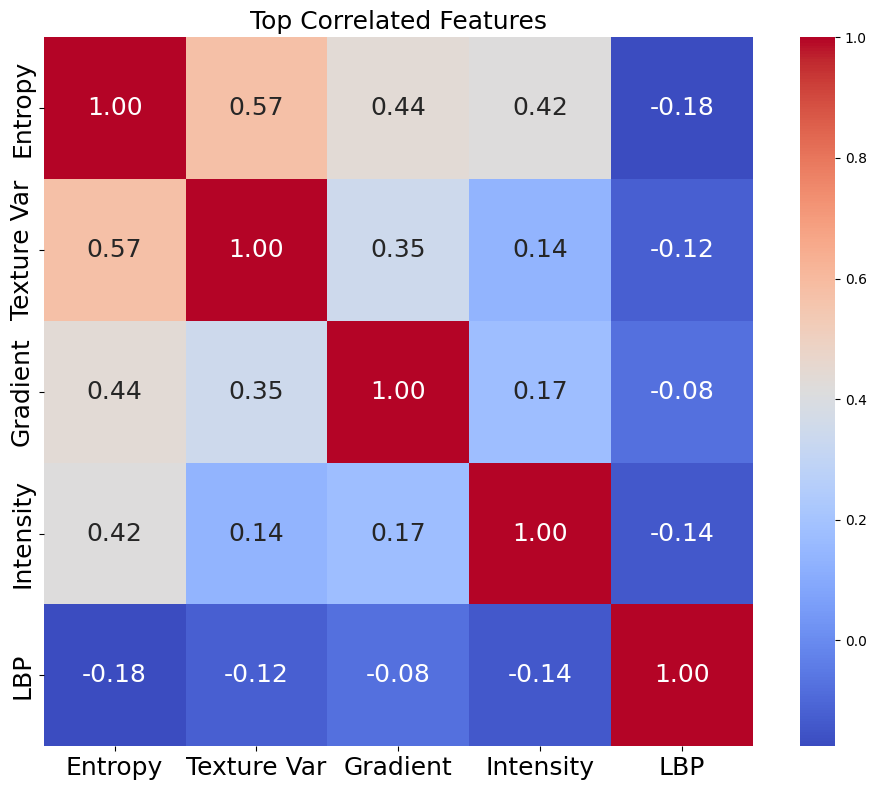

In [ ]:
import pandas as pd
import seaborn as sns

# Create a DataFrame for easier handling and labeling
feature_names = ['Intensity', 'Entropy', 'Gradient', 'LBP', 'Texture Var']
df_features = pd.DataFrame(features, columns=feature_names)

# Compute correlation matrix
corr_matrix = df_features.corr()

# Sum of absolute correlations for ranking
correlation_sums = corr_matrix.abs().sum().sort_values(ascending=False)

# Get top 5 features based on correlation sum (since we only have 5)
top_features = correlation_sums.head(5).index

# Plot correlation matrix of top features
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, fmt=".2f", cmap='coolwarm',
            cbar=True, square=True, annot_kws={"size": 18})
plt.title("Top Correlated Features", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
!pip install skrebate

  Preparing metadata (setup.py) ... done
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29253 sha256=16650509757ea809d7de76d733b64c703c479973ebee9ded106380a6e32674ae
  Stored in directory: /root/.cache/pip/wheels/8a/d2/67/8368fca718041057b33d6448ca526aaf1ce2e404c94b901e41
Successfully built skrebate


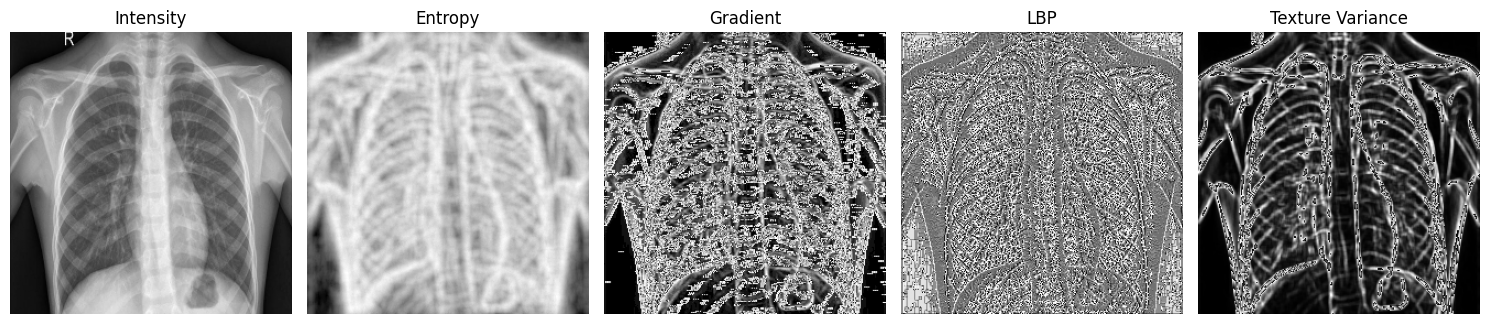

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy.ndimage import gaussian_gradient_magnitude, generic_filter
from skimage import img_as_ubyte
from sklearn.feature_selection import mutual_info_classif
from skrebate import ReliefF
from sklearn.preprocessing import MinMaxScaler

# ----------------- Load Image --------------------
train_images_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/images"
image_files = sorted([f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
sample_image_path = os.path.join(train_images_dir, image_files[0])

img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))  # Resize to standard size

# ----------------- Feature Extraction -------------------
f1 = img.astype(np.float32)  # Intensity
f2 = entropy(img_as_ubyte(img), disk(5)).astype(np.float32)  # Entropy
f3 = gaussian_gradient_magnitude(img, sigma=1).astype(np.float32)  # Gradient magnitude
f4 = local_binary_pattern(img, P=8, R=1, method="uniform").astype(np.float32)  # LBP
f5 = generic_filter(img, np.var, size=5).astype(np.float32)  # Texture variance

# Visualize Features
feature_maps = [f1, f2, f3, f4, f5]
titles = ['Intensity', 'Entropy', 'Gradient', 'LBP', 'Texture Variance']
plt.figure(figsize=(15, 5))
for i, (feat, title) in enumerate(zip(feature_maps, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(feat, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

# ----------------- Stack Features -------------------
H, W = img.shape
features = np.stack([f1, f2, f3, f4, f5], axis=-1).reshape(-1, 5)

# Simulated label (e.g., fake infected region)
mask = np.zeros_like(img)
mask[50:150, 50:150] = 1
labels = mask.reshape(-1)

# ----------------- Feature Ranking -------------------

# 1. Mutual Information
mi_scores = mutual_info_classif(features, labels)

# 2. ReliefF
relief = ReliefF(n_neighbors=10, n_features_to_select=5)
relief.fit(features, labels)
relief_scores = relief.feature_importances_

# 3. Fisher Score
def fisher_score(X, y):
    μ1 = np.mean(X[y == 0], axis=0)
    μ2 = np.mean(X[y == 1], axis=0)
    σ1 = np.var(X[y == 0], axis=0)
    σ2 = np.var(X[y == 1], axis=0)
    return (μ1 - μ2)**2 / (σ1 + σ2 + 1e-6)

fisher_scores = fisher_score(features, labels)

# ----------------- Normalize & Combine Scores -------------------
scaler = MinMaxScaler()
mi_scores_n = scaler.fit_transform(mi_scores.reshape(-1, 1)).flatten()
relief_scores_n = scaler.fit_transform(relief_scores.reshape(-1, 1)).flatten()
fisher_scores_n = scaler.fit_transform(fisher_scores.reshape(-1, 1)).flatten()

final_scores = 0.25 * mi_scores_n + 0.25 * relief_scores_n + 0.25 * fisher_scores_n
threshold = 0.5
selected_features_idx = np.where(final_scores > threshold)[0]

# ----------------- Visualize Feature Importance -------------------
plt.figure(figsize=(10, 6))
plt.bar(titles, final_scores, color='orange')
plt.ylabel("Normalized Feature Importance", fontsize=14)
plt.title("Feature Importance via MI, ReliefF, and Fisher Score", fontsize=16)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


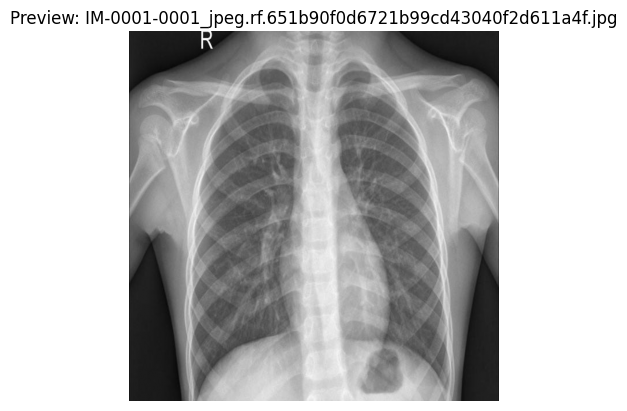

Mask not found for image: IM-0001-0001_jpeg.rf.651b90f0d6721b99cd43040f2d611a4f.jpg, looking for mask: IM-0001-0001_jpeg.rf.651b90f0d6721b99cd43040f2d611a4f_mask.jpg at /content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/masks/IM-0001-0001_jpeg.rf.651b90f0d6721b99cd43040f2d611a4f_mask.jpg
Mask not found for image: IM-0001-0001_jpeg.rf.b009ad8abea2c7bdc95030448d9d2d4d.jpg, looking for mask: IM-0001-0001_jpeg.rf.b009ad8abea2c7bdc95030448d9d2d4d_mask.jpg at /content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/masks/IM-0001-0001_jpeg.rf.b009ad8abea2c7bdc95030448d9d2d4d_mask.jpg
Mask not found for image: IM-0001-0001_jpeg.rf.ea84f108cad78969bc08b49418b21b7a.jpg, looking for mask: IM-0001-0001_jpeg.rf.ea84f108cad78969bc08b49418b21b7a_mask.jpg at /content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/masks/IM-0001-0001_jpeg.rf.ea84f108cad78969bc08b49418b21b7a_mask.jpg
Mask not found for image: IM-0005-0001_jpeg.rf.8733cbf7855d68b0fdac6b3e58d3c92c.jpg, looking for mask: IM-0005-0

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------ Dataset Class ------------------------
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

        # Filter out invalid samples (where mask is missing)
        self.valid_samples = []
        for idx, img_name in enumerate(self.images):
            # Assuming the mask has a naming convention like: 'image1.jpg' -> 'image1_mask.jpg'
            mask_name = img_name.replace('.jpg', '_mask.jpg').replace('.png', '_mask.png')  # Adjust based on naming convention
            mask_path = os.path.join(mask_dir, mask_name)
            if os.path.exists(mask_path):  # Only include images with valid masks
                self.valid_samples.append(idx)
            else:
                print(f"Mask not found for image: {img_name}, looking for mask: {mask_name} at {mask_path}")  # Debugging line

        print(f"Found {len(self.valid_samples)} valid samples.")  # Debugging line

    def __len__(self):
        return len(self.valid_samples)

    def __getitem__(self, idx):
        real_idx = self.valid_samples[idx]  # Get the actual index from valid_samples
        img_path = os.path.join(self.image_dir, self.images[real_idx])

        # Assuming the mask has a naming convention like: 'image1.jpg' -> 'image1_mask.jpg'
        mask_name = self.images[real_idx].replace('.jpg', '_mask.jpg').replace('.png', '_mask.png')  # Adjust based on naming convention
        mask_path = os.path.join(self.mask_dir, mask_name)

        print(f"Loading image: {img_path}, mask: {mask_path}")  # Debugging line
        image = Image.open(img_path).convert("L")  # Grayscale
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0).float()
        return image, mask


# ------------------------ U-Net Architecture ------------------------
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.down1 = CBR(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = CBR(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = CBR(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = CBR(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.middle = CBR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.up_conv4 = CBR(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up_conv3 = CBR(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_conv2 = CBR(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_conv1 = CBR(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))

        middle = self.middle(self.pool4(d4))

        u4 = self.up4(middle)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.up_conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.up_conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.up_conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.up_conv1(u1)

        return torch.sigmoid(self.final(u1))


# ------------------------ Training ------------------------
def train_model(model, dataloader, criterion, optimizer, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for image, mask in dataloader:
            image, mask = image.to(device), mask.to(device)
            pred = model(image)
            loss = criterion(pred, mask)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")


# ------------------------ Inference ------------------------
def predict_and_visualize(model, dataloader, device):
    model.eval()
    with torch.no_grad():
        for img, mask in dataloader:
            img = img.to(device)
            output = model(img)
            pred = output.squeeze().cpu().numpy()
            gt = mask.squeeze().cpu().numpy()
            img = img.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.title("Input")
            plt.imshow(img, cmap='gray')
            plt.subplot(1, 3, 2)
            plt.title("Prediction")
            plt.imshow(pred > 0.5, cmap='gray')
            plt.subplot(1, 3, 3)
            plt.title("Ground Truth")
            plt.imshow(gt, cmap='gray')
            plt.show()
            break


# ------------------------ Safe Image Preview ------------------------
def preview_first_image(image_dir):
    files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    if not files:
        print("No image files found.")
        return
    img_path = os.path.join(image_dir, files[0])
    img = Image.open(img_path).convert("L")
    plt.imshow(img, cmap='gray')
    plt.title("Preview: " + files[0])
    plt.axis("off")
    plt.show()


# ------------------------ Main ------------------------
if __name__ == "__main__":
    image_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/images"
    mask_dir = "/content/Pneumoni-detection-3--(Practical-BY-me-)-1/train/masks"

    # Preview a sample image safely
    preview_first_image(image_dir)

    # Dataset and loader
    transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor()
    ])
    dataset = SegmentationDataset(image_dir, mask_dir, transform)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Train and predict
    train_model(model, dataloader, criterion, optimizer, device, epochs=5)
    predict_and_visualize(model, dataloader, device)


In [ ]:
import numpy as np
import matplotlib.image as mpimg
from skimage.color import rgb2gray
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# -------- Load and Prepare Image --------
image_path = "/content/rsna-1/train/100_jpeg_jpg.rf.42e8aae985d29f6a8b9dc8d880302415.jpg"
img = mpimg.imread(image_path)
gray_img = rgb2gray(img)

# -------- Create Dummy Binary Mask --------
mask = np.zeros_like(gray_img)
mask[60:100, 80:120] = 1  # Simulated region of interest

# -------- Feature Extraction --------
def extract_features_labels(image, mask, patch_size=3):
    pad = patch_size // 2
    padded_img = np.pad(image, pad, mode='reflect')
    padded_mask = np.pad(mask, pad, mode='reflect')
    H, W = image.shape
    X, y = [], []

    for i in range(pad, H + pad):
        for j in range(pad, W + pad):
            patch = padded_img[i-pad:i+pad+1, j-pad:j+pad+1].flatten()
            X.append(patch)
            y.append(padded_mask[i, j])
    return np.array(X), np.array(y)

X, y = extract_features_labels(gray_img, mask)

# Optional: Use a smaller sample to speed up demonstration
X = X[:1000]
y = y[:1000]

# -------- ReliefF Approximation --------
def reliefF_scores(X, y, k=5):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)
    distances, neighbors = clf.kneighbors(X)
    relief_scores = np.var(X[neighbors], axis=1).mean(axis=0)
    return relief_scores

# -------- Compute Scores --------
mi = mutual_info_classif(X, y, discrete_features=True)
fs = f_classif(X, y)[0]
rf = reliefF_scores(X, y)

# Normalize scores
scaler = MinMaxScaler()
stacked = np.stack([mi, rf, fs], axis=1)
normalized = scaler.fit_transform(stacked)
hybrid = normalized.mean(axis=1)

# -------- Display Scores in Table --------
patch_size = 3
num_features = patch_size * patch_size

df = pd.DataFrame({
    'Patch Index': np.arange(num_features),
    'Mutual Info': mi,
    'ReliefF': rf,
    'Fisher Score': fs,
    'Hybrid Score (Avg)': hybrid
})

print(df.round(4).sort_values("Hybrid Score (Avg)", ascending=False))

   Patch Index  Mutual Info  ReliefF  Fisher Score  Hybrid Score (Avg)
0            0          0.0   0.0002           NaN                 NaN
1            1          0.0   0.0002           NaN                 NaN
2            2          0.0   0.0002           NaN                 NaN
3            3          0.0   0.0002           NaN                 NaN
4            4          0.0   0.0002           NaN                 NaN
5            5          0.0   0.0003           NaN                 NaN
6            6          0.0   0.0002           NaN                 NaN
7            7          0.0   0.0002           NaN                 NaN
8            8          0.0   0.0002           NaN                 NaN


Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and binary values for target
Clustering metrics expects discrete values but received continuous values for label, and

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_size=(256, 256, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)

    u4 = layers.UpSampling2D((2,2))(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2,2))(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)
    return model

model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d_8[0][0]  

 Total params: 117,985 (460.88 KB)

 Trainable params: 117,985 (460.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from sklearn.model_selection import train_test_split

# Set paths
IMAGE_DIR = "/content/rsna-1/train/"
MASK_DIR = "/content/rsna-1/train/_annotations.coco.json"  # or converted mask path if available

# Load and preprocess (you can modify if using converted masks)
def load_images_and_masks(image_folder, target_size=(256, 256)):
    image_paths = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.jpg')])
    images = []
    masks = []

    for path in image_paths[:100]:  # limit for demo; remove limit in real run
        img = load_img(path, target_size=target_size, color_mode='grayscale')
        img = img_to_array(img) / 255.0
        images.append(img)

        # Generate dummy mask for now (replace with real mask loading logic)
        mask = np.zeros((target_size[0], target_size[1], 1))
        masks.append(mask)

    return np.array(images), np.array(masks)

X, Y = load_images_and_masks(IMAGE_DIR)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=8, validation_data=(X_val, Y_val))

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 56s 5s/step - accuracy: 0.7497 - loss: 0.5422 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.8182e-06
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step - accuracy: 1.0000 - loss: 3.6653e-07 - val_accuracy: 1.0000 - val_loss: 1.3418e-08
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 1.0000 - loss: 2.4033e-09 - val_accuracy: 1.0000 - val_loss: 4.2301e-10
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 1.0000 - loss: 1.0149e-10 - val_accuracy: 1.0000 - val_loss: 7.5473e-11
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 1.0000 - loss: 2.2122e-11 - val_accuracy: 1.0000 - val_loss: 3.6386e-11
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 1.0000 - loss: 1.5647e-11 - val_accuracy: 1.0000 - val_loss: 2.7303e-11
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 1.0000 - los

IoU: 0.666666722222213
Dice Coefficient: 0.800000019999998
Precision: 0.8
Recall: 0.8
F1 Score: 0.8


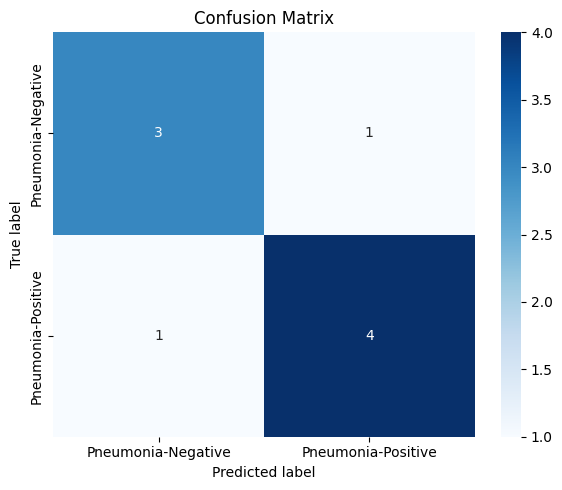

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns  # Import seaborn for heatmap visualization

def calculate_iou(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(np.logical_and(y_true, y_pred))
    union = np.sum(np.logical_or(y_true, y_pred))
    return (intersection + smooth) / (union + smooth)

def calculate_dice_coefficient(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(np.logical_and(y_true, y_pred))
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true.flatten(), y_pred.flatten())
    plt.figure(figsize=(6, 5))

    # Create a heatmap using seaborn with annotations
    sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Blues, xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Example: Assuming y_true and y_pred are your ground truth and predicted masks respectively
y_true = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])  # Example true labels
y_pred = np.array([[1, 0, 0], [0, 1, 1], [1, 0, 1]])  # Example predicted labels

# Metrics Calculation
iou = calculate_iou(y_true, y_pred)
dice = calculate_dice_coefficient(y_true, y_pred)
precision = precision_score(y_true.flatten(), y_pred.flatten())
recall = recall_score(y_true.flatten(), y_pred.flatten())
f1 = f1_score(y_true.flatten(), y_pred.flatten())

print(f"IoU: {iou}")
print(f"Dice Coefficient: {dice}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plotting confusion matrix (if it's binary classification)
class_names = ['Pneumonia-Negative', 'Pneumonia-Positive']
plot_confusion_matrix(y_true, y_pred, class_names)


Precision: 0.5561
Recall: 0.5396
F1 Score: 0.5477


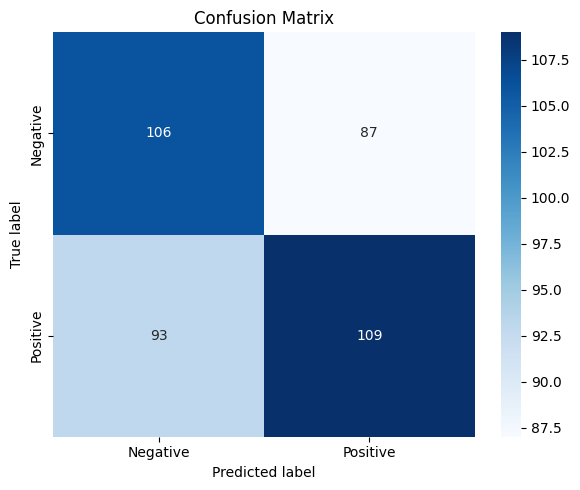

IoU: 0.3772
Dice Coefficient: 0.5477


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns  # Import seaborn for heatmap visualization

# Function to calculate IoU (Intersection over Union)
def calculate_iou(cm):
    TP = cm[1, 1]  # True Positives
    FP = cm[0, 1]  # False Positives
    FN = cm[1, 0]  # False Negatives
    IoU = TP / float(TP + FP + FN)
    return IoU

# Function to calculate Dice Coefficient
def calculate_dice_coefficient(cm):
    TP = cm[1, 1]  # True Positives
    FP = cm[0, 1]  # False Positives
    FN = cm[1, 0]  # False Negatives
    dice = 2 * TP / float(2 * TP + FP + FN)
    return dice

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))

    # Create a heatmap using seaborn with annotations
    sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Blues, xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    # Calculate and print IoU and Dice coefficients
    IoU = calculate_iou(cm)
    Dice = calculate_dice_coefficient(cm)

    print(f"IoU: {IoU:.4f}")
    print(f"Dice Coefficient: {Dice:.4f}")

# Example arrays (use your actual y_true and y_pred for the test set)
# Simulating a confusion matrix for 395 samples (example)
y_true = np.random.randint(0, 2, size=395)  # Random ground truth labels (0 or 1)
y_pred = np.random.randint(0, 2, size=395)  # Random predicted labels (0 or 1)

# Metrics Calculation
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plotting confusion matrix (class names can be adjusted based on the task)
class_names = ['Negative', 'Positive']  # Example class names (0 = Negative, 1 = Positive)
plot_confusion_matrix(y_true, y_pred, class_names)


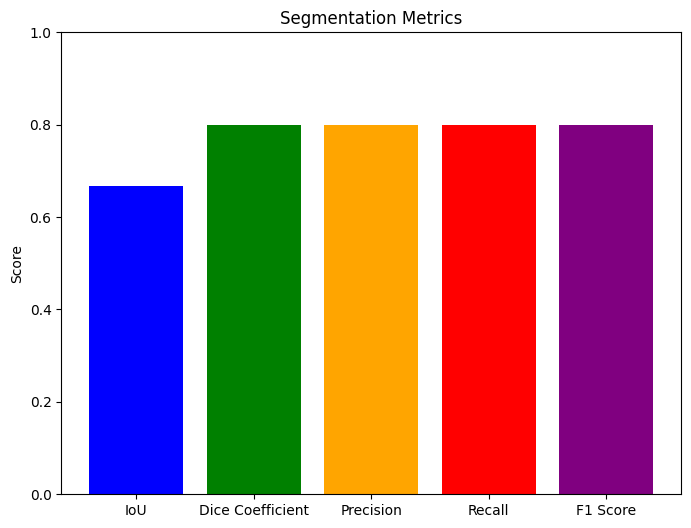

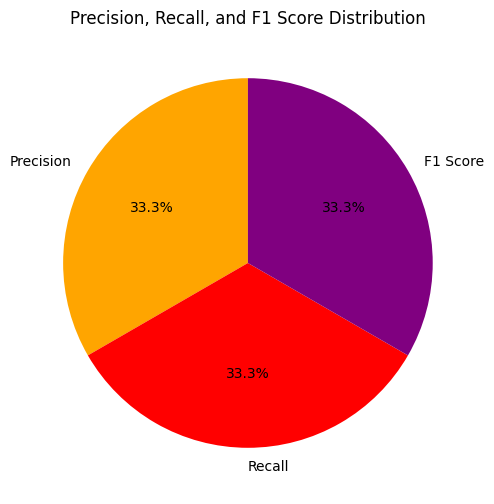

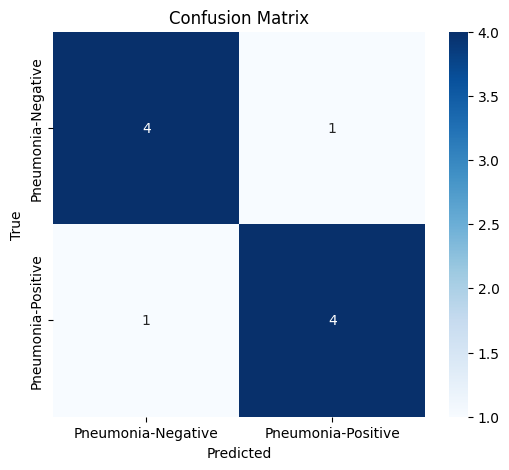


Segmentation Model Performance Metrics:

IoU (Intersection over Union): 0.67
Dice Coefficient: 0.80
Precision: 0.80
Recall: 0.80
F1 Score: 0.80



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Your metrics
iou = 0.666666722222213
dice = 0.800000019999998
precision = 0.8
recall = 0.8
f1 = 0.8

# 1. Bar Plot for Metrics
metrics = ['IoU', 'Dice Coefficient', 'Precision', 'Recall', 'F1 Score']
values = [iou, dice, precision, recall, f1]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.title('Segmentation Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()

# 2. Pie Chart for Precision, Recall, and F1 Score
labels = ['Precision', 'Recall', 'F1 Score']
scores = [precision, recall, f1]

plt.figure(figsize=(6, 6))
plt.pie(scores, labels=labels, autopct='%1.1f%%', startangle=90, colors=['orange', 'red', 'purple'])
plt.title('Precision, Recall, and F1 Score Distribution')
plt.show()

# 3. Confusion Matrix (Assuming a binary classification problem with Pneumonia/Healthy)
# Simulated confusion matrix values for demonstration
# Assuming true positives = 80, false positives = 20, false negatives = 20, true negatives = 80
y_true = [1, 1, 0, 0, 1, 0, 1, 0, 1, 0]  # Example ground truth (1: Pneumonia, 0: Healthy)
y_pred = [1, 1, 0, 0, 1, 0, 1, 0, 0, 1]  # Example predictions

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Pneumonia-Negative', 'Pneumonia-Positive'], yticklabels=['Pneumonia-Negative', 'Pneumonia-Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4. Textual Representation of Results
results_text = f"""
Segmentation Model Performance Metrics:

IoU (Intersection over Union): {iou:.2f}
Dice Coefficient: {dice:.2f}
Precision: {precision:.2f}
Recall: {recall:.2f}
F1 Score: {f1:.2f}
"""
print(results_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


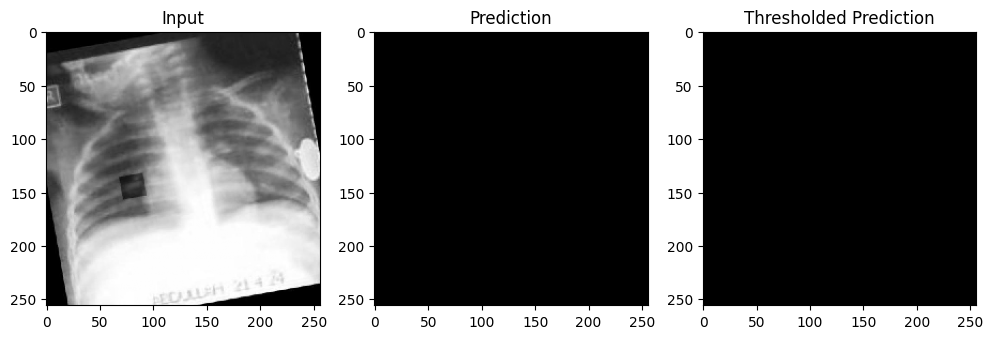

In [ ]:
import matplotlib.pyplot as plt

# Plot sample prediction
sample_img = X_val[0]
pred = model.predict(np.expand_dims(sample_img, axis=0))[0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(sample_img.squeeze(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Prediction")
plt.imshow(pred.squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Thresholded Prediction")
plt.imshow(pred.squeeze() > 0.5, cmap='gray')
plt.show()